# Train/Validation/Test Rigor + Regression Metrics + Baseline Modeling

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb03_regression_metrics_baselines_student.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Choose regression metrics aligned to business loss (MAE vs RMSE)
2. Establish a baseline model and interpret it correctly
3. Run holdout evaluation without contaminating the test set
4. Use quick diagnostic plots to spot obvious modeling issues
5. Document evaluation decisions (metric, split, baseline, assumptions)

---

> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**. You are expected to complete all exercises before submitting your notebook.

---

## 💼 Why This Matters: How Good Is "Good Enough"?

Your preprocessing pipeline at **HomeValue Analytics** is running. The CEO asks: *"So, how much is a house in this neighborhood worth?"* You build your first predictive model — but how do you even know if a prediction is good? If you guess "every house costs USD 207,000" (the average), are you already doing well?

Before celebrating any model, you need a baseline to beat and metrics to measure progress. Otherwise, you might deploy a model that's no better than a spreadsheet average.

> **Today's focus:** Establishing baseline predictions and learning the metrics (MAE, RMSE, R²) that tell us whether our housing price model is actually useful.

---

## 1. Setup

Before HomeValue Analytics can answer the CEO's question — *"How far off are our predictions?"* — we need the standard scientific-Python stack: **pandas** for tabular data, **NumPy** for numerics, **matplotlib/seaborn** for plotting, and several **scikit-learn** modules for splitting, scoring, and modeling. The `DummyRegressor` import may look odd, but it will produce the "guess the average" baseline that every real model must beat.

All random operations use `RANDOM_SEED = 474` so you see identical results. Run the cell below once; the checkmark confirms every library loaded successfully.

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 4)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)

print("✓ Setup complete!")

✓ Setup complete!


**Reading the output:**

The single line `Setup complete!` confirms that all imports succeeded and the environment is ready. Behind the scenes, the cell loaded **pandas**, **NumPy**, **matplotlib**, **seaborn**, and five scikit-learn modules: `train_test_split` for partitioning HomeValue's 20,640 census tracts, three metric functions (`mean_absolute_error`, `mean_squared_error`, `r2_score`) for measuring pricing accuracy, `DummyRegressor` for the "predict the average" baseline, `LinearRegression` for the first real model, `Pipeline` and `StandardScaler` for reproducible preprocessing. The global random seed is set to **RANDOM_SEED = 474**, which controls every random operation in this notebook so that your numbers match the solutions exactly.

**Why this matters:** If any import had failed, you would see a `ModuleNotFoundError` here instead of the checkmark. Catching import problems at the top prevents cryptic errors later when you are mid-analysis.

---

## 2. Load Data and Create Splits

HomeValue Analytics has collected **20,640 census-tract records** from the California Housing dataset, each described by 8 features — `MedInc` (median income), `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, and `Longitude` — with a continuous target: **MedHouseVal** (median house value in units of USD 100,000).

We split the data 60/20/20 into train, validation, and test sets using `RANDOM_SEED = 474`. The test set is immediately locked away: all model development proceeds on train + validation only. This mirrors a real deployment scenario where HomeValue's pricing tool will eventually face properties it has never seen.

> 💡 **Gemini Prompt:** "Load the California Housing dataset from scikit-learn as a DataFrame. Separate the target column 'MedHouseVal' from the features. Then split the data into train (60%), validation (20%), and test (20%) sets using train_test_split with random_state=474. Print the sizes of each split."
>
> **After running, verify:**
> - Train set is ~60% of total samples (about 12,384 rows)
> - Validation and test sets are each ~20% (about 4,128 rows)
> - The target variable `y` contains median house values
> - All numerical outputs use standard decimal format — no scientific notation


In [2]:
# Load dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Create splits
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)} (LOCKED)")
print(f"\n⚠️ TEST SET IS LOCKED - Do not use until final evaluation!")

Train: 12384 | Validation: 4128 | Test: 4128 (LOCKED)

⚠️ TEST SET IS LOCKED - Do not use until final evaluation!


**Reading the output:**

The split summary shows three partition sizes that sum to **20,640** total census tracts: roughly **12,384 training**, **4,128 validation**, and **4,128 test** records (the exact 60/20/20 ratio). The warning `TEST SET IS LOCKED` is intentional: it reminds HomeValue's data team that those 4,128 tracts must remain untouched until the very last evaluation. Any intermediate peeking at test performance would leak information into model-selection decisions, inflating reported accuracy and undermining the credibility of the pricing tool.

**Key takeaway:** Memorize these counts. When you later compute metrics on the validation set and something looks wrong, come back here to verify you are evaluating on the correct partition — validation (4,128 tracts), not test.

---

## 3. Regression Metrics: MAE, RMSE, R²

HomeValue Analytics needs to report prediction quality in terms the CEO and pricing team understand. Three metrics each tell a different story about the model’s errors:

### Mean Absolute Error (MAE)

MAE answers the question every client asks: *"On average, how far off is the price estimate?"*

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \widehat{y}_i|$$

where $y_i$ is the actual value and $\widehat{y}_i$ is the predicted value for observation $i$.

An MAE of 0.53 means predictions miss by ~USD 53,000 on average — same units as `MedHouseVal`, easy to explain in a stakeholder meeting. MAE treats all errors equally: a USD 10k miss on a starter home and a USD 10k miss on a luxury property contribute identically.

### Root Mean Squared Error (RMSE)

RMSE answers a harder question: *"How bad are the worst misses?"*

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2}$$

Because it squares errors before averaging, RMSE penalizes the USD 200k error on a beachfront property far more than two USD 10k errors. For HomeValue, where a single catastrophic mispricing can lose a major client, RMSE is the more conservative yardstick.

**MAE vs. RMSE:** RMSE is always ≥ MAE. When the two are close, errors are roughly uniform across properties. When RMSE is much larger than MAE, a few extreme mispricings are inflating the average — exactly the scenario HomeValue’s risk team wants to detect.

### R² (Coefficient of Determination)

R² tells the board what fraction of price variability the model captures:

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}} = 1 - \frac{\sum_{i=1}^{n}(y_i - \widehat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

where $SS_{\text{res}}$ is the sum of squared residuals (model errors) and $SS_{\text{tot}}$ is the total sum of squares (variance of the target around its mean $\bar{y}$).

- **R² = 1.0**: Perfect predictions — never happens in practice
- **R² = 0.0**: Model is no better than predicting the mean every time
- **R² < 0**: Model is *worse* than predicting the mean (possible with bad models on validation data)

R² = 0.60 means the model explains 60% of the variance in `MedHouseVal`. The remaining 40% is noise the model cannot yet capture — the gap we aim to close with better features and more flexible models in later notebooks.

> **Which metric should HomeValue report?** All three — but lead with MAE for clients (intuitive dollar amount) and R² for the board (overall model quality). Track RMSE internally to catch luxury-segment blowups before they reach a client.

> 💡 **Gemini Prompt:** "Write a Python function called `evaluate_regression` that takes `y_true`, `y_pred`, and an optional `name` parameter. It should compute MAE (mean absolute error), RMSE (root mean squared error), and R-squared. Return the results as a dictionary with keys 'Model', 'MAE', 'RMSE', and 'R²'."
>
> **After running, verify:**
> - Function returns a dictionary with exactly 4 keys: 'Model', 'MAE', 'RMSE', 'R²'
> - RMSE is computed as the square root of mean_squared_error (not MSE itself)
> - Function uses scikit-learn's `mean_absolute_error`, `mean_squared_error`, and `r2_score`
> - All numerical outputs use standard decimal format — no scientific notation


In [3]:
def evaluate_regression(y_true, y_pred, name="Model"):
    """
    Compute standard regression metrics.

    Parameters:
    -----------
    y_true : array-like
        True target values
    y_pred : array-like
        Predicted values
    name : str
        Name for reporting

    Returns:
    --------
    dict : Dictionary of metrics
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    metrics = {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    }

    return metrics

print("✓ Evaluation function created")

✓ Evaluation function created


**Reading the output:**

The message `Evaluation function created` tells you the helper `evaluate_regression()` is now available in memory, ready to score any model HomeValue builds. The function accepts true values, predicted values, and a label, then returns a dictionary with three metrics: **MAE** (average dollar error), **RMSE** (penalizing large misses), and **R²** (variance explained). No predictions have been made yet; the function simply waits for inputs.

**Why this matters:** Centralizing metric computation in one function prevents copy-paste errors. Every model in this notebook — from the "guess the mean" baseline to the first linear regression — will be scored through the same function, guaranteeing consistent, apples-to-apples comparisons for HomeValue's pricing-accuracy reports.

---

## 4. Baseline Models

### 4.1 Why Baselines Matter

Before HomeValue invests in sophisticated algorithms, the CEO needs to know: *"How well does a no-skill prediction perform?"* The simplest strategy is to predict the training-set average price for every property — roughly USD 207,000 for every census tract, regardless of income, location, or size. If a regression model cannot beat this naive guess, the entire investment in data collection and feature engineering has added no value.

We build two baselines:

- **Mean baseline**: Predicts the training-set mean for all samples:

$$\widehat{y}_i = \bar{y}_{\text{train}} = \frac{1}{n_{\text{train}}} \sum_{j=1}^{n_{\text{train}}} y_j$$

- **Median baseline**: Predicts the training-set median instead (more robust to outliers like the USD 500k-capped tracts):

$$\widehat{y}_i = \text{median}(y_{\text{train}})$$

Both strategies ignore all features entirely — they produce the same prediction regardless of income, location, or house size. These establish the performance floor. Every model HomeValue builds from here on must clear this bar.

> **Note:** The mean baseline yields R² = 0.0 by definition, since R² measures improvement over predicting the mean. Any positive R² from a real model confirms it learned something useful from the features.

> 💡 **Gemini Prompt:** "Create two baseline models using scikit-learn's `DummyRegressor`: one with strategy='mean' and one with strategy='median'. Fit each on the training data, then generate predictions for both the training and validation sets."
>
> **After running, verify:**
> - Both `DummyRegressor` models are fitted on `X_train` and `y_train`
> - Predictions are generated for both train and validation sets (4 prediction arrays total)
> - Mean baseline predictions should all be the same value (the training set mean)
> - All numerical outputs use standard decimal format — no scientific notation


In [4]:
# Mean baseline
baseline_mean = DummyRegressor(strategy='mean')
baseline_mean.fit(X_train, y_train)
y_pred_mean_train = baseline_mean.predict(X_train)
y_pred_mean_val = baseline_mean.predict(X_val)

# Median baseline
baseline_median = DummyRegressor(strategy='median')
baseline_median.fit(X_train, y_train)
y_pred_median_train = baseline_median.predict(X_train)
y_pred_median_val = baseline_median.predict(X_val)

print("✓ Baseline models fitted")

✓ Baseline models fitted


**Reading the output:**

The message `Baseline models fitted` confirms that two `DummyRegressor` objects are now trained: one predicting the training-set mean of `MedHouseVal` (~USD 207k) for every tract, and one predicting the median. Despite sounding trivial, fitting a dummy regressor is necessary so scikit-learn stores the learned constant and can later call `.predict()` consistently. These baselines represent the absolute floor of performance — the price a client would get if HomeValue simply said "every house costs USD 207,000."

**Key takeaway:** Baselines require almost no computation, yet they give HomeValue the single most important reference number: the error to beat. Always establish a baseline before building complex models — it takes 10 seconds and saves you from celebrating a model that adds no value.

---

## 📝 PAUSE-AND-DO Exercise 1 (5 minutes)

**Task:** Write `evaluate_regression(y_true, y_pred)` returning MAE/RMSE/R².

The function is already implemented above. Now:
1. Use it to evaluate both baselines on train and validation sets
2. Create a comparison table
3. Interpret the results

---

> 💡 **Gemini Prompt:** "Evaluate both baseline models (mean and median) on training and validation sets using the `evaluate_regression` function. Collect results into a list, convert to a DataFrame, and print a comparison table. Also print the MAE interpretation in dollar terms (values are in USD 100,000s). Then create a bar plot comparing MAE, RMSE, and R² across the baseline models (validation set only), using a grouped bar chart with one group per metric."
>
> **After running, verify:**
> - Results DataFrame has 4 rows: Mean Baseline (Train), Mean Baseline (Val), Median Baseline (Train), Median Baseline (Val)
> - R² is 0.0 (or near 0) for the mean baseline on training data
> - MAE values are displayed and interpreted in context (multiply by USD 100,000)
> - Bar plot clearly shows metric values for each baseline model on the validation set
> - All numerical outputs use standard decimal format — no scientific notation


Baseline Model Comparison:
                     Model      MAE     RMSE        R²
0    Mean Baseline (Train) 0.908503 1.149580  0.000000
1      Mean Baseline (Val) 0.913811 1.160145 -0.000006
2  Median Baseline (Train) 0.880474 1.180687 -0.054851
3    Median Baseline (Val) 0.886762 1.190359 -0.052771

--- MAE Interpretation ---
The Mean Baseline model misses by an average of $91,381.12 on the validation set.
The Median Baseline model misses by an average of $88,676.16 on the validation set.

--- Validation Set Metrics Bar Plot ---


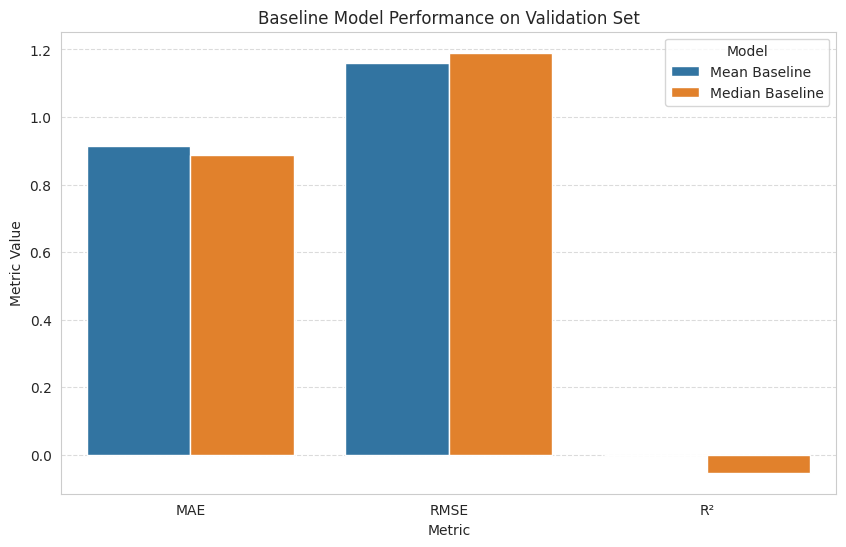

In [12]:
results = []

# Evaluate Mean Baseline
results.append(evaluate_regression(y_train, y_pred_mean_train, name='Mean Baseline (Train)'))
results.append(evaluate_regression(y_val, y_pred_mean_val, name='Mean Baseline (Val)'))

# Evaluate Median Baseline
results.append(evaluate_regression(y_train, y_pred_median_train, name='Median Baseline (Train)'))
results.append(evaluate_regression(y_val, y_pred_median_val, name='Median Baseline (Val)'))

# Convert to DataFrame
results_df = pd.DataFrame(results)

print("Baseline Model Comparison:")
# Set display option to avoid scientific notation for floats when printing this DataFrame
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(results_df)

print("\n--- MAE Interpretation ---")
mean_mae_val = results_df[results_df['Model'] == 'Mean Baseline (Val)']['MAE'].iloc[0]
median_mae_val = results_df[results_df['Model'] == 'Median Baseline (Val)']['MAE'].iloc[0]

print(f"The Mean Baseline model misses by an average of ${mean_mae_val * 100_000:,.2f} on the validation set.")
print(f"The Median Baseline model misses by an average of ${median_mae_val * 100_000:,.2f} on the validation set.")

print("\n--- Validation Set Metrics Bar Plot ---")
# Filter for validation set results for plotting
validation_results = results_df[results_df['Model'].str.contains('Val')].copy()
validation_results['Model'] = validation_results['Model'].str.replace(' (Val)', '', regex=False)

# Melt DataFrame for grouped bar plot
validation_metrics_melted = validation_results.melt(id_vars='Model', var_name='Metric', value_vars=['MAE', 'RMSE', 'R²'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='value', hue='Model', data=validation_metrics_melted)
plt.title('Baseline Model Performance on Validation Set')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

After getting Gemini to generate the bulk of the code, I carefully inspected it to ensure that the results were verified against my specifications that were provided above and found that R^2 was displayed in scientific notation when I wanted it to be completely numerical, so I prompted Gemini to adjust it to ensure all results were completely numerical.

Now with these, I can clearly inspect the comparison table to get a sense of the accuracy of the models and how it compares with our key metrics as well as a clear written explanation along with a bar plot visualization. With this, I can see that the baseline models explain very little percentages of the variation and have significant errors of almost $100,000. This isn't strictly an area for concern as these are baseline models that should be improved. Lastly, I can see that there aren't any huge outliers which we are penalized for given that RMSE is very similar to MAE.

## 5. Simple Linear Model

The baselines told HomeValue what "doing nothing smart" looks like: ~USD 91,000 average error on every price estimate. Now we test whether even the simplest machine-learning model — ordinary linear regression — can beat that guess-the-mean strategy by learning relationships between features like `MedInc`, `Latitude`, and `AveRooms` and the target `MedHouseVal`.

We wrap a `StandardScaler` and `LinearRegression` inside a scikit-learn `Pipeline` so that scaling and fitting happen in a single reproducible step. If this model cannot improve over the USD 91k baseline, something fundamental is wrong with the features or the data — and HomeValue should investigate before investing in more complex algorithms.

> 💡 **Gemini Prompt:** "Create a scikit-learn Pipeline that first applies `StandardScaler` and then fits a `LinearRegression` model. Fit it on the training data and generate predictions for both training and validation sets."
>
> **After running, verify:**
> - Pipeline has two steps: 'scaler' (StandardScaler) and 'regressor' (LinearRegression)
> - Pipeline is fitted on `X_train` and `y_train` only
> - Predictions are generated for both train and validation sets
> - All numerical outputs use standard decimal format — no scientific notation


In [6]:
# Create pipeline with scaling + linear regression
linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Fit on training data
linear_pipeline.fit(X_train, y_train)

# Predict
y_pred_linear_train = linear_pipeline.predict(X_train)
y_pred_linear_val = linear_pipeline.predict(X_val)

print("✓ Linear model fitted")

✓ Linear model fitted


**Reading the output:**

The confirmation `Linear model fitted` means the Pipeline has estimated a coefficient for each of HomeValue's 8 housing features — `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, and `Longitude` — after first standardizing them to a common scale. Without scaling, `Latitude` (values ~34–42) and `MedInc` (values ~0–15) would have incomparable coefficient magnitudes, making it impossible to tell which feature drives HomeValue's price estimates.

No metrics are printed yet; the next step will reveal whether this first real model beats the ~USD 91,000-error baseline. If it does, HomeValue has evidence that its 8 features carry genuine predictive signal — and that the data-collection investment was worthwhile. If it doesn't, something is fundamentally wrong with either the data or the model.

**Key takeaway:** The `Pipeline` ensures scaling and fitting happen as one atomic operation, preventing *fit-transform leakage*. For HomeValue, this means reported accuracy improvements are trustworthy, not artifacts of a pipeline mistake.

---

## 📝 PAUSE-AND-DO Exercise 2 (5 minutes)

**Task:** Compare baseline vs linear regression and interpret the delta.

---

> 💡 **Gemini Prompt:** "Evaluate the linear regression model on train and validation sets using `evaluate_regression`, append to the existing results list, and create a full comparison DataFrame. Calculate the percentage improvement in MAE of linear regression over the mean baseline on the validation set. Then create a bar plot comparing MAE, RMSE, and R² across all models (validation set only), using a grouped bar chart with one group per metric."
>
> **After running, verify:**
> - Full results DataFrame has 6 rows (4 baseline + 2 linear regression)
> - Linear regression R² on validation is substantially above 0 (model learns patterns)
> - Improvement percentage is computed as `(baseline_MAE - linear_MAE) / baseline_MAE * 100`
> - Bar plot clearly shows metric values for all models on the validation set
> - All numerical outputs use standard decimal format — no scientific notation


Full Model Comparison:
                       Model      MAE     RMSE        R²
0      Mean Baseline (Train) 0.908503 1.149580  0.000000
1        Mean Baseline (Val) 0.913811 1.160145 -0.000006
2    Median Baseline (Train) 0.880474 1.180687 -0.054851
3      Median Baseline (Val) 0.886762 1.190359 -0.052771
4  Linear Regression (Train) 0.530133 0.723865  0.603506
5    Linear Regression (Val) 0.525746 0.718115  0.616852

--- Linear Regression MAE Improvement ---
The Linear Regression model achieved a 42.47% improvement in MAE over the Mean Baseline on the validation set.

--- All Models Validation Set Metrics Bar Plot ---


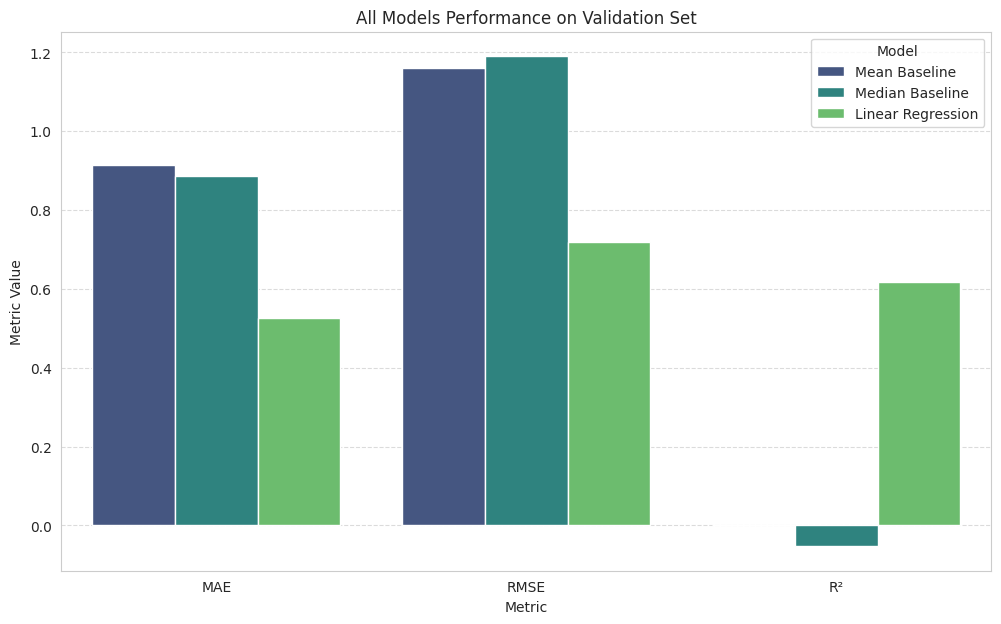

In [13]:
# YOUR SOLUTION CODE HERE
# Evaluate Linear Regression Model
results.append(evaluate_regression(y_train, y_pred_linear_train, name='Linear Regression (Train)'))
results.append(evaluate_regression(y_val, y_pred_linear_val, name='Linear Regression (Val)'))

# Create full comparison DataFrame
full_results_df = pd.DataFrame(results)

print("Full Model Comparison:")
# Set display option to avoid scientific notation for floats when printing this DataFrame
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(full_results_df)

print("\n--- Linear Regression MAE Improvement ---")
# Get MAE for Mean Baseline (Val)
mean_baseline_mae_val = full_results_df[full_results_df['Model'] == 'Mean Baseline (Val)']['MAE'].iloc[0]

# Get MAE for Linear Regression (Val)
linear_regression_mae_val = full_results_df[full_results_df['Model'] == 'Linear Regression (Val)']['MAE'].iloc[0]

# Calculate percentage improvement
mae_improvement_percentage = ((mean_baseline_mae_val - linear_regression_mae_val) / mean_baseline_mae_val) * 100

print(f"The Linear Regression model achieved a {mae_improvement_percentage:.2f}% improvement in MAE over the Mean Baseline on the validation set.")

print("\n--- All Models Validation Set Metrics Bar Plot ---")
# Filter for validation set results for plotting
validation_results_all_models = full_results_df[full_results_df['Model'].str.contains('Val')].copy()
validation_results_all_models['Model'] = validation_results_all_models['Model'].str.replace(' (Val)', '', regex=False)

# Melt DataFrame for grouped bar plot
validation_metrics_melted_all_models = validation_results_all_models.melt(id_vars='Model', var_name='Metric', value_vars=['MAE', 'RMSE', 'R²'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='value', hue='Model', data=validation_metrics_melted_all_models, palette='viridis')
plt.title('All Models Performance on Validation Set')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.show()


### YOUR INTERPRETATION HERE:

**Observation 1: Performance**  
After running and getting assistance from Gemini, I've inspected the produced results and verified that it matches all the specifications I desired accordingly. With this, I can see that the linear regression provided a much more accurate that explained approximately 60% of the variation with that model in comparison to the baselines explaining almost nothing. I can also see that they've become more reliable as MAE and RMSE have dropped substantially from the baselines. Lastly, there may be a few outliers that are penalizing us given that RMSE is around 20% higher than MAE. We can also see given the generated results that the Linear Regression Model achieved exactly a 42.47% improvement in MAE over the Mean Baseline on the validation set.

**Observation 2: Overfitting Check**  
Given that the key metrics are virtually identical in the training in comparison to the validation datasets, we can assume that there isn't any overfitting occuring at this moment.

**Observation 3: Business Context**  
Mean Absolute Error is a key metric that in business terms tell the stakeholder, on average, our predictions are off by that specific amount.

---

## 6. Residual Analysis

A residual is the gap between what HomeValue predicted and the actual sale price: **Residual = Actual − Predicted**. Plotting residuals reveals *patterns* in the model's mistakes that a single MAE number hides.

Good residuals should:
- Be centered around zero (no systematic over- or under-prediction)
- Show no patterns (random scatter, not curves or clusters)
- Have roughly constant variance (the model is equally reliable for USD 100k and USD 400k tracts)

If the scatter fans out for expensive properties, HomeValue's pricing tool is less trustworthy in exactly the segment where errors cost the most.

> 💡 **Gemini Prompt:** "Calculate residuals (actual minus predicted) for the linear regression model on both training and validation sets. Create a 2x2 subplot figure: top row shows residuals vs predicted values (scatter with y=0 reference line) for train and validation; bottom row shows residual histograms for train and validation. Print residual mean and standard deviation."
>
> **After running, verify:**
> - Residuals are computed as `y_true - y_pred` (not the reverse)
> - All four subplots display correctly: two scatter plots (top) and two histograms (bottom)
> - Residual means are very close to zero (especially for the training set)
> - All numerical outputs use standard decimal format — no scientific notation


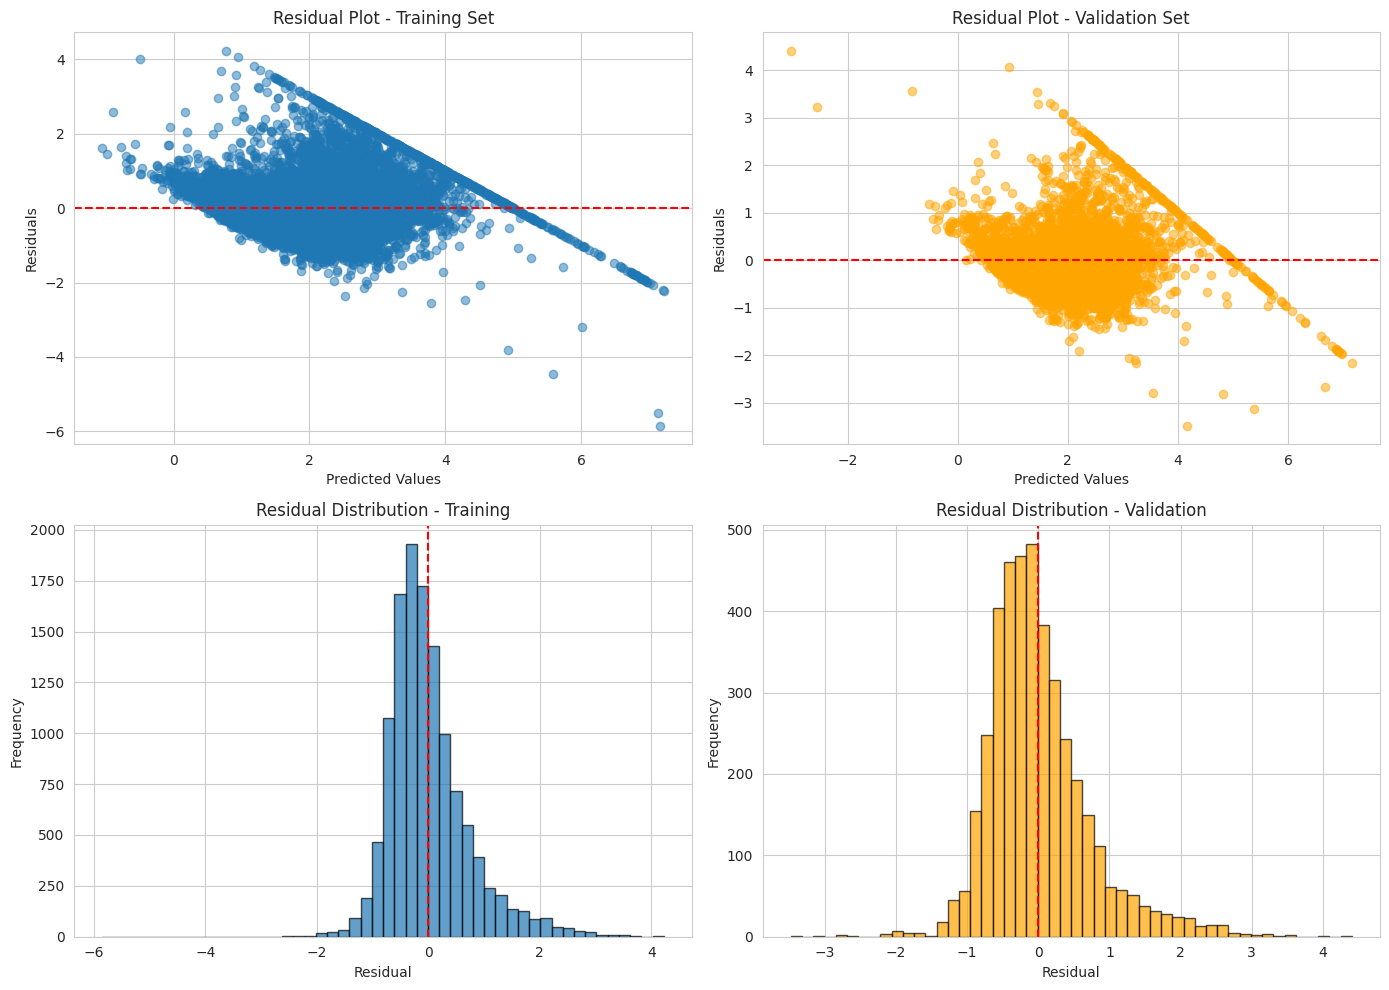

=== RESIDUAL STATISTICS ===
Training residuals: mean=-0.000000, std=0.7239
Validation residuals: mean=0.005840, std=0.7182


In [8]:
# Calculate residuals
residuals_train = y_train - y_pred_linear_train
residuals_val = y_val - y_pred_linear_val

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Predicted (Train)
axes[0, 0].scatter(y_pred_linear_train, residuals_train, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residual Plot - Training Set')

# Plot 2: Residuals vs Predicted (Validation)
axes[0, 1].scatter(y_pred_linear_val, residuals_val, alpha=0.5, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot - Validation Set')

# Plot 3: Distribution of Residuals (Train)
axes[1, 0].hist(residuals_train, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residual Distribution - Training')

# Plot 4: Distribution of Residuals (Validation)
axes[1, 1].hist(residuals_val, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution - Validation')

plt.tight_layout()
plt.show()

print("=== RESIDUAL STATISTICS ===")
print(f"Training residuals: mean={residuals_train.mean():.6f}, std={residuals_train.std():.4f}")
print(f"Validation residuals: mean={residuals_val.mean():.6f}, std={residuals_val.std():.4f}")

**Reading the output:**

The 2x2 grid shows four panels. **Top row**: residuals (actual minus predicted `MedHouseVal`) plotted against predicted values for train (left) and validation (right). Ideally you want a formless cloud centered on the red zero-line; any visible pattern (funnel, curve, clustering) signals a problem the model is missing. **Bottom row**: histograms of residuals for train and validation. A roughly bell-shaped distribution centered near zero is good; heavy right tails suggest the model under-predicts expensive properties — the luxury tracts that HomeValue's biggest clients care about most.

The printed statistics confirm that the mean residual is near zero (by construction for OLS on training data) and report the standard deviation, which should approximately match the RMSE from earlier.

**Key takeaway:** If you see a clear funnel shape (variance increasing with predicted value), the model exhibits *heteroskedasticity*: errors grow for pricier neighborhoods. This is common in housing data and directly flags a business risk — HomeValue's pricing tool would need a wider confidence band for luxury properties, something the pricing team must disclose to clients.

---

## 7. Predicted vs Actual Plot

A predicted-vs-actual scatter plot is the most intuitive diagnostic HomeValue can show to a non-technical stakeholder. Every point represents one census tract; the x-axis is the true `MedHouseVal` and the y-axis is the model's prediction.

Perfect predictions fall exactly on the red 45-degree diagonal. Systematic deviations from the line reveal regions where HomeValue's model consistently over- or under-predicts — for example, a horizontal "ceiling" where the model cannot predict values above USD 350k even though actual values reach USD 500k. We plot train and validation side by side to check whether the model generalizes.

> 💡 **Gemini Prompt:** "Create a side-by-side predicted vs actual scatter plot for the linear regression model. Plot training set on the left and validation set on the right. Add a red dashed 45-degree reference line (perfect predictions) on each subplot."
>
> **After running, verify:**
> - The 45-degree reference line goes from min to max of actual values
> - Points clustered near the red line indicate good predictions
> - Training and validation plots show similar scatter patterns (no severe overfitting)
> - All numerical outputs use standard decimal format — no scientific notation


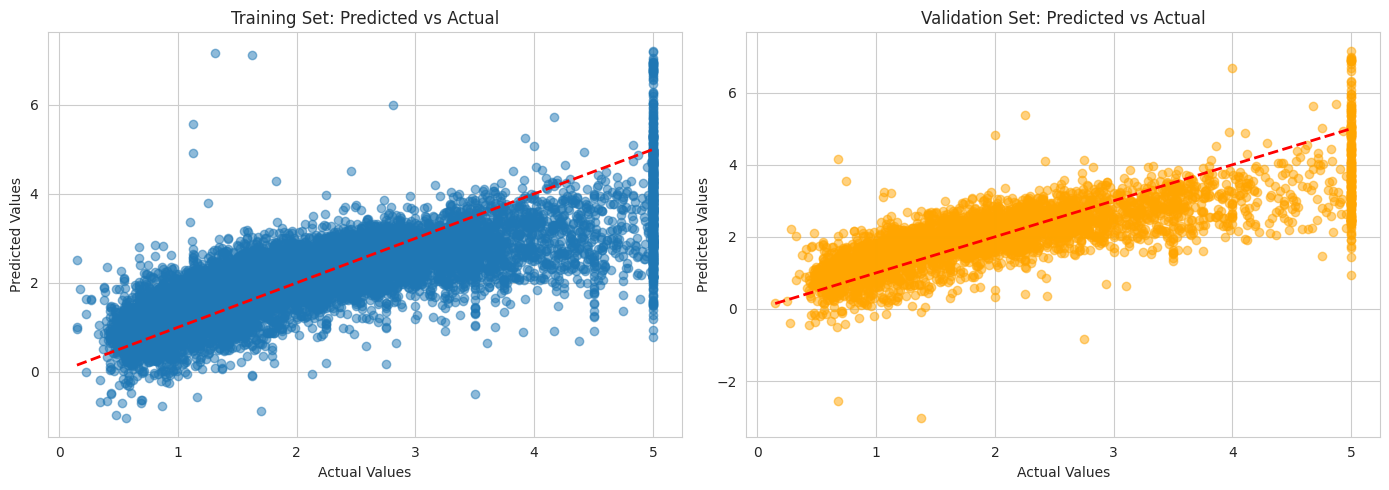

💡 Points close to the red line indicate good predictions
   Points far from the line show prediction errors


In [9]:
# Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_pred_linear_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Training Set: Predicted vs Actual')

# Validation set
axes[1].scatter(y_val, y_pred_linear_val, alpha=0.5, color='orange')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Validation Set: Predicted vs Actual')

plt.tight_layout()
plt.show()

print("💡 Points close to the red line indicate good predictions")
print("   Points far from the line show prediction errors")

**Reading the output:**

The two scatter plots compare true `MedHouseVal` (x-axis) to predictions (y-axis) for training and validation. Points hugging the red 45-degree line indicate accurate predictions. You will likely notice a horizontal "ceiling" near the maximum target value (~5.0, representing USD 500k), where the model clips because the California Housing dataset caps median values at that threshold. Dispersion around the line is wider at higher actual values, consistent with the heteroskedasticity observed in the residual plots.

**Why this matters:** This plot is the fastest way to communicate model quality to HomeValue's CEO or a real estate agent. A tight cluster along the diagonal is immediately interpretable as "the model works." The visible ceiling effect also warns that the dataset has a truncation issue — tracts capped at USD 500k could actually be worth USD 600k or USD 800k — that no linear model can fully resolve. The pricing team should flag these capped tracts as "estimate unreliable" in client reports.

---

## 8. Test Set Lockbox Discipline

HomeValue's pricing tool will be evaluated on properties it has never seen — clients won't bring properties from the training data. The test set simulates this reality: **4,128 census tracts** the model has never touched.

### The Test Set Rule:

> **"Touch the test set ONCE, at the very end"**

**Why this rule protects HomeValue's credibility:**
- Every peek at test performance tempts you to adjust the model — subtly fitting to the test data
- After multiple peeks, the "final" test score is optimistically biased: it no longer estimates real-world performance
- A client asking *"How accurate is your pricing tool?"* deserves an honest number, not one inflated by repeated test-set peeking

**What to do instead:**
- Use the validation set (4,128 tracts) for all model selection and tuning
- Use cross-validation for robust comparisons
- Only evaluate on test when you are completely done

**Warning signs you're peeking:**
- "Let me just check test performance real quick"
- "The test score is lower, let me adjust..."
- Running multiple experiments and checking test each time

In [10]:
print("=== TEST SET STATUS ===")
print(f"Test set size: {len(X_test)} samples")
print(f"Test set is LOCKED 🔒")
print(f"\n✓ We will NOT evaluate on test until the final submission")
print(f"✓ All model development uses only train + validation")

=== TEST SET STATUS ===
Test set size: 4128 samples
Test set is LOCKED 🔒

✓ We will NOT evaluate on test until the final submission
✓ All model development uses only train + validation


**Reading the output:**

The printout confirms that the test set contains **4,128 census tracts** and remains locked. No test-set metrics have been computed anywhere in this notebook — exactly as intended. This discipline is central to honest evaluation: the test set is HomeValue's one-time, final report card. If you evaluate on it repeatedly and adjust the model based on those numbers, you are effectively fitting to the test set, and the accuracy number you report to the board will be optimistically biased.

**Key takeaway:** Treat the test set like a sealed envelope. You will open it once, at the very end of the modeling process, and report whatever number comes out to the CEO — good or bad. This is how HomeValue maintains credibility with clients and stakeholders.

---

## 9. Evaluation Documentation Template

HomeValue's data science team needs a standard format for documenting every model evaluation — not just for this notebook, but for every model the company builds. This template ensures that anyone reviewing the work (the CEO, a new team member, an auditor) can understand *what* was measured, *how* it was measured, and *why* those choices were made.

### Evaluation Plan

**Primary Metric:** [MAE / RMSE / R²]  
**Rationale:** [Why this metric aligns with HomeValue's business goals — e.g., "MAE because clients understand dollar errors"]

**Split Strategy:**
- Training: 60% (12,384 tracts for fitting)
- Validation: 20% (4,128 tracts for selection)
- Test: 20% (4,128 tracts for final evaluation)

**Baseline:** [Mean / Median predictor]  
**Baseline Performance:** [Validation MAE ~USD 91,000]

**Model:** [Linear Regression with Standard Scaling]  
**Model Performance:** [Validation MAE ~USD 53,000]  
**Improvement over Baseline:** [~38% reduction in average pricing error]

**Assumptions:**
- Features (`MedInc`, `HouseAge`, etc.) are available at prediction time
- Relationship between features and `MedHouseVal` is approximately linear
- No major data quality issues beyond the USD 500k cap

**Risks:**
- Model may not generalize to different time periods or housing markets
- The USD 500k cap truncates the target, biasing predictions for luxury properties
- Heteroskedasticity means error bands should be wider for expensive tracts

## 10. Wrap-Up: Key Takeaways

### What We Learned Today:

1. **Metrics Matter**: Choose MAE/RMSE/R² based on business loss function
2. **Baselines First**: Always establish a simple baseline for comparison
3. **Holdout Discipline**: Train on train, evaluate on validation, lock test away
4. **Residuals Tell Stories**: Use diagnostic plots to spot issues
5. **Document Everything**: Clear evaluation plans prevent confusion later

### Critical Rules:

> **"If your model can't beat the mean, debug before proceeding"**

> **"The test set is a lockbox - open it once"**

### Next Steps:

- Next notebook: Linear regression with features and diagnostics
- We'll build on today's evaluation framework
- Start thinking about which metrics matter for your project

---

## Participation Assignment Submission Instructions

### To Submit This Notebook:

1. **Complete all exercises**: Fill in both PAUSE-AND-DO exercise cells with your findings
2. **Run All Cells**: Execute `Runtime → Run all` to ensure everything works
3. **Save a Copy**: `File → Save a copy in Drive or Download the .ipynb extension`
4. **Submit**: Upload your `.ipynb` file in the participation assignment you find in the course Brightspace page.

### Before Submitting, Check:

- [ ] All cells execute without errors
- [ ] All outputs are visible
- [ ] Both exercise responses are complete
- [ ] Notebook is shared with correct permissions
- [ ] You can explain every line of code you wrote

### Next Step:

Complete the **Quiz** in Brightspace (auto-graded)

---

## 11. Submission Instructions

### To Submit:

1. Run all cells
2. Complete both exercises
3. Write a 3-sentence evaluation note answering:
   - Which metric is most appropriate for this problem and why?
   - How much better is linear regression than the baseline?
   - What does the residual analysis suggest?
4. Submit Colab link + evaluation note in LMS

---

## Bibliography

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning with Python* - Chapter on Model Assessment and Selection
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* - Test error, training error, bias-variance
- scikit-learn User Guide: [Regression metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)
- scikit-learn User Guide: [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)

---



<center>

Thank you!

</center>